# Atividade 4 — Segmentação, Morfologia e Extração de Características

## 1. Introdução

Nesta atividade eu desenvolvo um pipeline simples de visão computacional para segmentar uma imagem, aplicar operações morfológicas, identificar objetos por componentes conectados e extrair características numéricas.

Eu optei por usar uma imagem do meu próprio mini-dataset, pois o enunciado permite trabalhar com imagem capturada pelo estudante. A imagem escolhida contém uma placa eletrônica com vários componentes e regiões de textura, o que torna possível observar objetos, padrões e pequenas estruturas durante a segmentação.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage

plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['figure.figsize'] = (10, 6)

LARGURA_PADRAO = 800
AREA_MINIMA = 200
AREA_MAXIMA_PROPORCAO = 0.25


## 2. Aquisição da Imagem

Nesta etapa eu carrego a imagem original e faço um redimensionamento para 800 pixels de largura, mantendo a proporção. Esse ajuste deixa a visualização menor no notebook e reduz o custo das próximas etapas sem alterar a estrutura geral da cena.

A imagem contém uma placa STM32N6-DK fotografada de frente. Nela aparecem múltiplos componentes eletrônicos, conectores, áreas claras, áreas escuras e pequenas marcações. Esses elementos formam regiões de interesse adequadas para testar segmentação, morfologia e extração de características.


Arquivo: STM32N6-DK-frontal.jpeg
Formato: JPEG
Resolução original: 1600 x 900 px
Resolução usada no notebook: 800 x 450 px


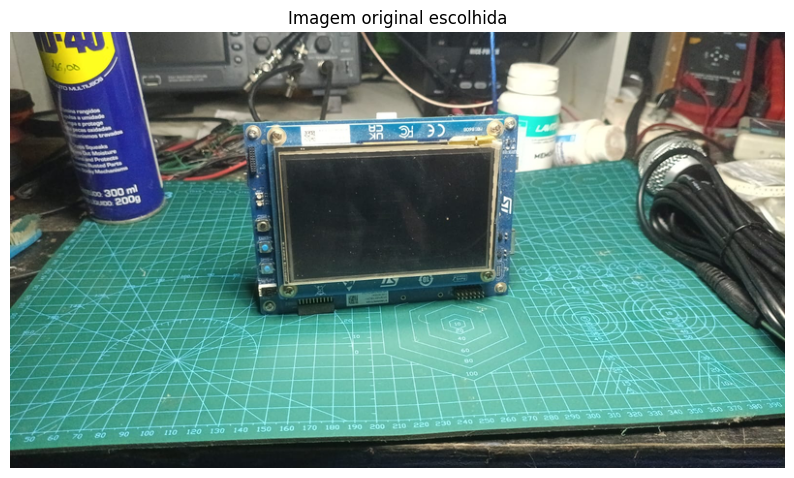

In [2]:
def localizar_dataset():
    candidatos = [Path.cwd() / 'dataset', Path.cwd().parent / 'dataset']
    for candidato in candidatos:
        if candidato.exists():
            return candidato
    raise FileNotFoundError('Não encontrei a pasta dataset.')


def carregar_imagem(caminho, largura=LARGURA_PADRAO):
    with Image.open(caminho) as img_pil:
        formato = img_pil.format or caminho.suffix.lower().replace('.', '').upper()
        img_rgb = img_pil.convert('RGB')
        largura_original, altura_original = img_rgb.size
        escala = largura / largura_original
        nova_altura = int(round(altura_original * escala))
        img_rgb = img_rgb.resize((largura, nova_altura), Image.Resampling.LANCZOS)
        imagem_rgb = np.array(img_rgb)
        imagem_cinza = np.array(img_rgb.convert('L'))

    metadados = {
        'arquivo': caminho.name,
        'formato': formato,
        'resolucao_original': f'{largura_original} x {altura_original}',
        'resolucao_usada': f'{largura} x {nova_altura}',
    }
    return imagem_rgb, imagem_cinza, metadados


dataset = localizar_dataset()
caminho_imagem = dataset / 'classe_A' / 'STM32N6-DK-frontal.jpeg'
if not caminho_imagem.exists():
    caminho_imagem = sorted((dataset / 'classe_A').glob('*'))[0]

imagem_rgb, imagem_cinza, metadados = carregar_imagem(caminho_imagem)

print(f"Arquivo: {metadados['arquivo']}")
print(f"Formato: {metadados['formato']}")
print(f"Resolução original: {metadados['resolucao_original']} px")
print(f"Resolução usada no notebook: {metadados['resolucao_usada']} px")

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(imagem_rgb)
ax.set_title('Imagem original escolhida')
ax.axis('off')
plt.show()


## 3. Segmentação

Para separar regiões de interesse, eu transformo a imagem para tons de cinza e aplico limiarização global pelo método de Otsu. Eu escolhi esse método porque ele calcula automaticamente um limiar a partir do histograma da imagem, sem precisar definir o valor manualmente.

Como a placa possui fundo claro e várias regiões internas com diferentes intensidades, eu segmentei as áreas mais claras após o limiar. Depois, nas etapas seguintes, eu removo componentes muito grandes, objetos encostados na borda e ruídos pequenos para manter regiões mais úteis na análise.


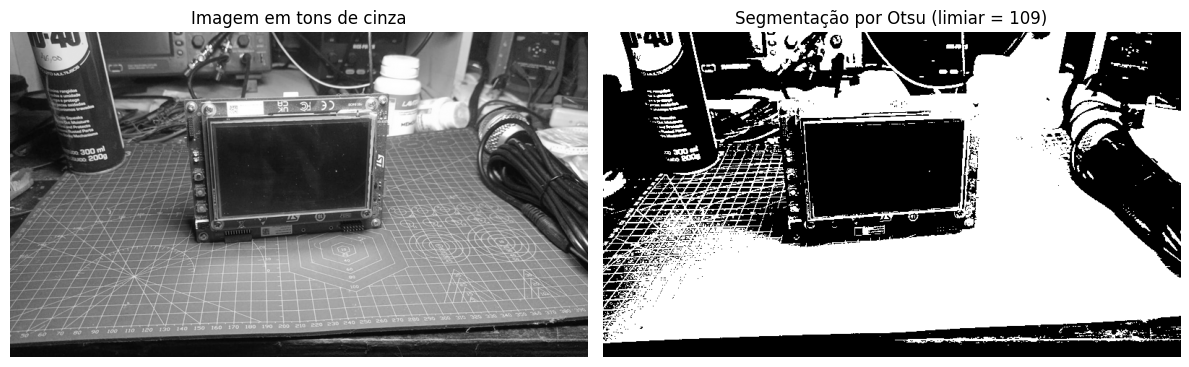

Limiar encontrado: 109


In [3]:
def limiar_otsu(imagem):
    histograma, _ = np.histogram(imagem.ravel(), bins=256, range=(0, 256))
    probabilidades = histograma / histograma.sum()
    pesos = np.cumsum(probabilidades)
    medias = np.cumsum(probabilidades * np.arange(256))
    media_total = medias[-1]
    variancia_entre_classes = (media_total * pesos - medias) ** 2 / (pesos * (1 - pesos) + 1e-12)
    return int(np.nanargmax(variancia_entre_classes))


limiar = limiar_otsu(imagem_cinza)
segmentada = imagem_cinza > limiar

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(imagem_cinza)
axes[0].set_title('Imagem em tons de cinza')
axes[0].axis('off')

axes[1].imshow(segmentada)
axes[1].set_title(f'Segmentação por Otsu (limiar = {limiar})')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print('Limiar encontrado:', limiar)


### Discussão da Segmentação

Eu escolhi a limiarização de Otsu porque ela é simples, automática e funciona como uma boa primeira tentativa quando existe contraste entre regiões claras e escuras.

A principal dificuldade que eu observei é que a imagem real não possui iluminação perfeitamente uniforme. Algumas partes da placa, sombras e reflexos podem ser confundidos com regiões de interesse. Além disso, algumas estruturas pequenas ficam próximas umas das outras e podem aparecer conectadas.

Mesmo com essas limitações, eu considero a segmentação suficiente para continuar o pipeline, porque ela separa várias regiões visíveis da placa e cria uma máscara binária que pode ser refinada com operações morfológicas.


## 4. Operações Morfológicas

Depois da segmentação, eu aplico abertura e fechamento. A abertura tenta remover pequenos ruídos e pontos isolados. O fechamento tenta preencher pequenas falhas e deixar algumas regiões segmentadas mais contínuas.

Essas duas operações ajudam a transformar a segmentação inicial em uma máscara mais adequada para a identificação dos objetos.


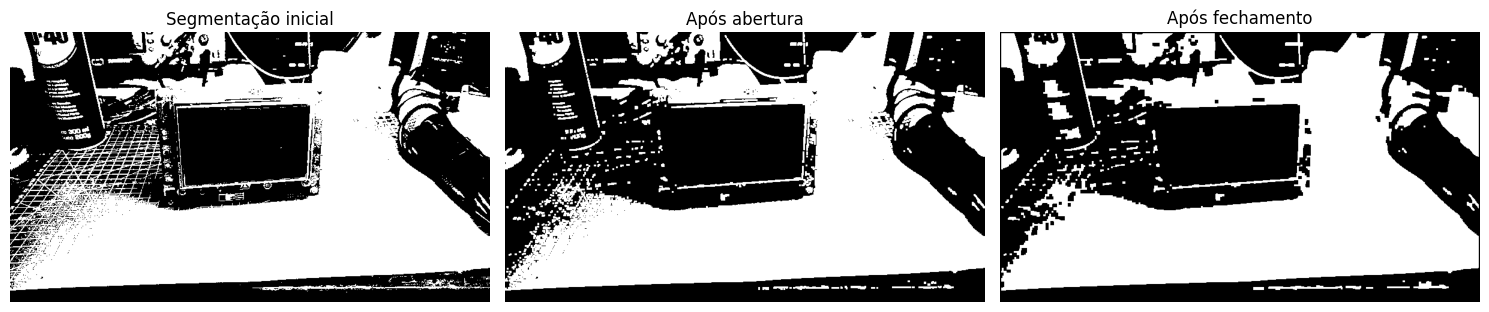

In [4]:
estrutura_abertura = np.ones((3, 3), dtype=bool)
estrutura_fechamento = np.ones((5, 5), dtype=bool)

abertura = ndimage.binary_opening(segmentada, structure=estrutura_abertura, iterations=1)
fechamento = ndimage.binary_closing(abertura, structure=estrutura_fechamento, iterations=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
etapas = [
    ('Segmentação inicial', segmentada),
    ('Após abertura', abertura),
    ('Após fechamento', fechamento),
]

for ax, (titulo, imagem) in zip(axes, etapas):
    ax.imshow(imagem)
    ax.set_title(titulo)
    ax.axis('off')

plt.tight_layout()
plt.show()


### Discussão das Operações Morfológicas

Na minha análise, a abertura reduziu pequenas regiões isoladas que apareciam como ruído na segmentação inicial. Ela também removeu partes muito finas que não eram tão estáveis.

O fechamento ajudou a unir pequenas quebras dentro de algumas regiões e deixou certos objetos mais preenchidos. A mudança mais perceptível foi uma máscara mais limpa e com estruturas menos fragmentadas, embora ainda existam erros causados por iluminação e contraste.


## 5. Identificação de Objetos

Nesta etapa eu uso análise de componentes conectados. Cada grupo de pixels conectados na máscara refinada é tratado como um possível objeto.

Para evitar que o fundo, bordas da imagem ou ruídos muito pequenos prejudiquem a contagem, eu filtro os componentes por área e removo componentes que encostam nas bordas da imagem.


Componentes encontrados antes da filtragem: 119
Objetos mantidos após filtragem: 19


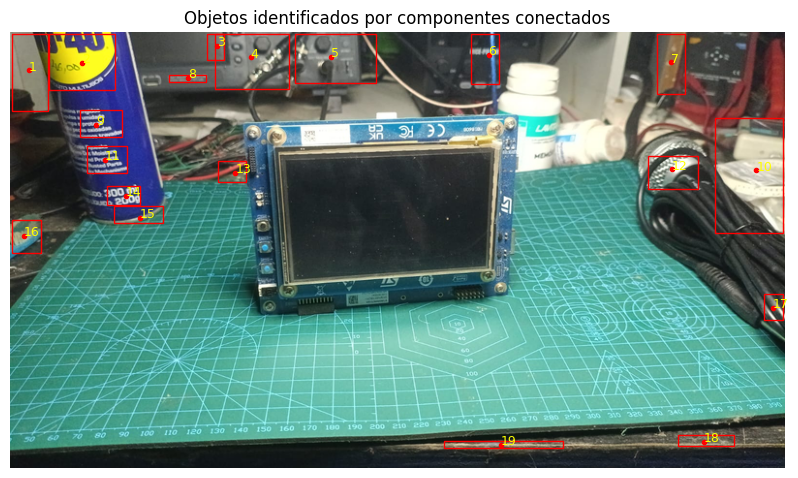

In [5]:
def propriedades_componentes(mascara, area_minima=AREA_MINIMA, area_maxima_proporcao=AREA_MAXIMA_PROPORCAO):
    rotulos_brutos, total_bruto = ndimage.label(mascara)
    altura, largura = mascara.shape
    area_maxima = mascara.size * area_maxima_proporcao

    objetos = []
    mascara_filtrada = np.zeros_like(rotulos_brutos, dtype=np.int32)
    novo_rotulo = 1

    for rotulo in range(1, total_bruto + 1):
        ys, xs = np.where(rotulos_brutos == rotulo)
        area = len(xs)
        if area < area_minima or area > area_maxima:
            continue
        if ys.min() == 0 or xs.min() == 0 or ys.max() == altura - 1 or xs.max() == largura - 1:
            continue

        objeto = rotulos_brutos == rotulo
        mascara_filtrada[objeto] = novo_rotulo
        objetos.append({
            'rotulo': novo_rotulo,
            'mascara': objeto,
            'area': area,
            'centroide_y': ys.mean(),
            'centroide_x': xs.mean(),
            'bbox': (ys.min(), xs.min(), ys.max(), xs.max()),
        })
        novo_rotulo += 1

    return mascara_filtrada, objetos, total_bruto


rotulos, objetos, total_bruto = propriedades_componentes(fechamento)

print('Componentes encontrados antes da filtragem:', total_bruto)
print('Objetos mantidos após filtragem:', len(objetos))

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(imagem_rgb)

for obj in objetos:
    y = obj['centroide_y']
    x = obj['centroide_x']
    y_min, x_min, y_max, x_max = obj['bbox']
    ax.plot(x, y, 'r.')
    ax.text(x, y, str(obj['rotulo']), color='yellow', fontsize=9)
    ax.add_patch(plt.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        fill=False,
        edgecolor='red',
        linewidth=1,
    ))

ax.set_title('Objetos identificados por componentes conectados')
ax.axis('off')
plt.show()


### Discussão da Identificação

Eu observei que vários componentes foram identificados na imagem, principalmente regiões claras e detalhes internos da placa. Nem todos correspondem a objetos físicos completos; alguns representam partes de componentes, marcações ou regiões com brilho.

A identificação não é perfeita porque a segmentação por limiar global pode separar um mesmo componente em várias partes ou unir regiões que estão próximas. As principais causas de erro são reflexos, sombras, contraste irregular e proximidade entre estruturas pequenas.


## 6. Extração de Características

Para cada objeto identificado, eu extraio características geométricas. No mínimo, o enunciado pede três características; aqui eu uso área, perímetro, centroide, largura, altura e razão de aspecto.

Essas medidas ajudam a descrever quantitativamente cada região detectada e permitem comparar os objetos entre si.


In [6]:
def calcular_perimetro(mascara):
    erodida = ndimage.binary_erosion(mascara, structure=np.ones((3, 3), dtype=bool))
    borda = mascara & ~erodida
    return int(borda.sum())


dados = []
for obj in objetos:
    y_min, x_min, y_max, x_max = obj['bbox']
    largura = x_max - x_min + 1
    altura = y_max - y_min + 1
    perimetro = calcular_perimetro(obj['mascara'])

    dados.append({
        'Objeto': obj['rotulo'],
        'Área': obj['area'],
        'Perímetro aproximado': perimetro,
        'Centroide_X': round(obj['centroide_x'], 2),
        'Centroide_Y': round(obj['centroide_y'], 2),
        'Largura': largura,
        'Altura': altura,
        'Razão de aspecto': round(largura / altura, 2),
    })

tabela = pd.DataFrame(dados)
tabela


,Objeto,Área,Perímetro aproximado,Centroide_X,Centroide_Y,Largura,Altura,Razão de aspecto
0,1,2079,234,19.10,38.91,38,80,0.48
1,2,2254,324,74.09,31.36,69,58,1.19
2,3,356,85,212.91,13.42,18,27,0.67
3,4,2424,323,247.89,25.70,77,57,1.35
4,5,2360,441,330.59,25.41,84,51,1.65
5,6,332,162,493.56,22.83,30,52,0.58
6,7,887,180,682.16,30.80,30,62,0.48
7,8,252,90,182.86,47.15,39,8,4.88
8,9,712,152,88.28,95.61,44,29,1.52
9,10,5069,448,769.82,142.26,71,120,0.59


## 7. Análise dos Resultados

Eu percebo que as características extraídas ajudam a distinguir as regiões detectadas. A área e o perímetro são as medidas mais informativas para separar objetos maiores de pequenos detalhes. A largura, a altura e a razão de aspecto também ajudam a diferenciar regiões alongadas de regiões mais compactas.

O centroide não é tão útil para dizer que tipo de objeto foi encontrado, mas é importante para saber onde cada região está localizada na imagem.

O pipeline poderia ser melhorado com limiarização adaptativa, ajuste de iluminação antes da segmentação, escolha de uma região de interesse da placa e uso de watershed ou contornos para separar estruturas muito próximas. Também seria possível extrair descritores de textura para representar melhor componentes com padrões internos.


## 8. Conclusão

Nesta atividade eu construí um pipeline completo de visão computacional usando uma imagem do meu dataset. Primeiro eu carreguei e descrevi a imagem, depois apliquei segmentação por Otsu, refinei a máscara com abertura e fechamento, identifiquei componentes conectados e extraí características em forma de tabela.

Eu concluo que técnicas simples já conseguem organizar a análise da imagem e gerar informações úteis sobre regiões detectadas. Ao mesmo tempo, percebi que imagens reais exigem cuidados extras, porque iluminação, reflexos, sombras e proximidade entre objetos podem afetar bastante a qualidade da segmentação.
